**Import Required Libraries**

In [ ]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score

import matplotlib.pyplot as plt

**Load Dataset**

In [ ]:
data = pd.read_csv("/content/data.csv")

print("First 5 rows of dataset:")
data.head()

First 5 rows of dataset:


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


**Explore dataset**

In [ ]:
print("Dataset Shape:", data.shape)
print("\nColumn Names:")
print(data.columns)

print("\nMissing Values:")
print(data.isnull().sum())

print("\nDataset Info:")
data.info()

print("\nStatistical Summary:")
data.describe()

Dataset Shape: (37309, 8)

Column Names:
Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country'],
      dtype='object')

Missing Values:
InvoiceNo          0
StockCode          0
Description      117
Quantity           0
InvoiceDate        0
UnitPrice          1
CustomerID     12880
Country            1
dtype: int64

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 37309 entries, 0 to 37308
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   InvoiceNo    37309 non-null  object 
 1   StockCode    37309 non-null  object 
 2   Description  37192 non-null  object 
 3   Quantity     37309 non-null  int64  
 4   InvoiceDate  37309 non-null  object 
 5   UnitPrice    37308 non-null  float64
 6   CustomerID   24429 non-null  float64
 7   Country      37308 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 2.3+ MB

Statistical 

,Quantity,UnitPrice,CustomerID
count,37309.000000,37308.000000,24429.000000
mean,8.011901,6.230193,15540.025339
std,61.414804,148.693371,1731.742013
min,-9360.000000,0.000000,12347.000000
25%,1.000000,1.280000,14210.000000
50%,2.000000,2.510000,15570.000000
75%,7.000000,4.250000,17158.000000
max,2880.000000,13541.330000,18269.000000


**Feature Engineering**

In [ ]:
product_data = data.groupby('StockCode').agg({
    'Quantity': 'sum',
    'TotalPrice': 'sum',
    'InvoiceNo': 'nunique'
})

product_data.columns = ['Total_Units_Sold', 'Total_Revenue', 'Order_Frequency']

**Data Preprocessing**

In [ ]:
def remove_outliers_iqr(df, columns):
    for col in columns:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        df = df[(df[col] >= lower_bound) & (df[col] <= upper_bound)]
    return df

product_data_clean = remove_outliers_iqr(
    product_data,
    ['Total_Units_Sold', 'Total_Revenue']
)

print("Original size:", product_data.shape)
print("After removing outliers:", product_data_clean.shape)

product_data_clean = product_data_clean[
    (product_data_clean['Total_Units_Sold'] > 0) &
    (product_data_clean['Total_Revenue'] > 0)
]

product_data_clean['Log_Units'] = np.log1p(product_data_clean['Total_Units_Sold'])
product_data_clean['Log_Revenue'] = np.log1p(product_data_clean['Total_Revenue'])

product_data_clean = product_data_clean.replace([np.inf, -np.inf], np.nan)
product_data_clean = product_data_clean.dropna()

data = data.dropna(subset=['CustomerID'])
data['InvoiceDate'] = pd.to_datetime(data['InvoiceDate'])
data['TotalPrice'] = data['Quantity'] * data['UnitPrice']

features = product_data_clean[['Log_Units', 'Log_Revenue']]
scaler = StandardScaler()
scaled_data = scaler.fit_transform(features)

Original size: (2362, 7)
After removing outliers: (1888, 7)


**Create ML Pipelines**

In [ ]:
models = {
    "KMeans": Pipeline([
        ('scaler', StandardScaler()),
        ('model', KMeans(n_clusters=3, random_state=42))
    ]),

    "Hierarchical": Pipeline([
        ('scaler', StandardScaler()),
        ('model', AgglomerativeClustering(n_clusters=3))
    ]),

    "DBSCAN": Pipeline([
        ('scaler', StandardScaler()),
        ('model', DBSCAN(eps=0.5, min_samples=10))
    ]),

    "GMM": Pipeline([
        ('scaler', StandardScaler()),
        ('model', GaussianMixture(n_components=3, random_state=42))
    ])
}

**Train and Evaluate All Models**

In [ ]:
scores = {}

for name, model in models.items():
    print(f"\n{name}")
    labels = model.fit_predict(scaled_data)
    product_data_clean[f"{name}_Cluster"] = labels
    unique_labels = set(labels)

    if -1 in unique_labels:
        unique_labels.remove(-1)

    if len(unique_labels) > 1:
        score = silhouette_score(scaled_data, labels)
        scores[name] = score
        print(f"Silhouette Score: {score:.4f}")
    else:
        scores[name] = "Not Valid"
        print("Silhouette Score: Not valid (single cluster / noise)")

K=2, Score=0.5246
K=3, Score=0.4405
K=4, Score=0.3908
K=5, Score=0.3901
K=6, Score=0.3654
K=7, Score=0.3770

Best K: 2 with score 0.5246

KMeans
Silhouette Score: 0.4405

Hierarchical
Silhouette Score: 0.4171

DBSCAN
Silhouette Score: Not valid (single cluster / noise)

GMM
Silhouette Score: 0.4369


**Model Comparison**

In [ ]:
print("Model Comparison:")
for model, score in scores.items():
    print(f"{model}: {score}")


Model Comparison:
KMeans: 0.5601942365809855
Hierarchical: 0.6223670575551078
DBSCAN: 0.5492823469872653
GMM: 0.5611892141240769


**Best Model Selection**

In [ ]:
valid_scores = {k: v for k, v in scores.items() if v != "Not Valid"}

if valid_scores:
    best_model = max(valid_scores, key=valid_scores.get)
    print(f"\nBest Model: {best_model} ({valid_scores[best_model]:.4f})")
else:
    print("\nNo valid clustering found.")


Best Model: Hierarchical (0.6224)


**Visualization**

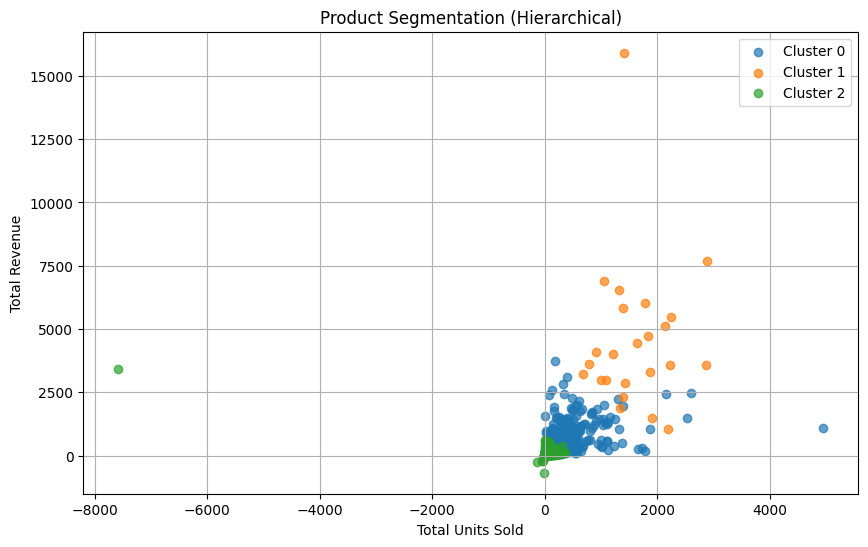

In [ ]:
if valid_scores:
    plt.figure(figsize=(10, 6))
    labels = product_data[f"{best_model}_Cluster"]
    unique_clusters = np.unique(labels)

    for cluster in unique_clusters:
        cluster_data = product_data[labels == cluster]

        plt.scatter(
            cluster_data['Total_Units_Sold'],
            cluster_data['Total_Revenue'],
            label=f"Cluster {cluster}",
            alpha=0.7
        )

    if best_model == "KMeans":
        kmeans_pipeline = models["KMeans"]
        kmeans_model = kmeans_pipeline.named_steps['model']
        scaler = kmeans_pipeline.named_steps['scaler']

        centers_scaled = kmeans_model.cluster_centers_
        centers = scaler.inverse_transform(centers_scaled)

    plt.xlabel("Total Units Sold")
    plt.ylabel("Total Revenue")
    plt.title(f"Product Segmentation ({best_model})")

    plt.legend()
    plt.grid()
    plt.show()